# Training/Validation Visualization Notebook
Visualizes model predictions on training/validation split with ground truth overlay.
Mirrors the visualizer's evaluation figure generation approach.

In [19]:
# === Parameters ===
MODEL_PATH = "models/model_epoch_20.pth"   # model checkpoint path

assert MODEL_PATH, "MODEL_PATH required"

In [20]:
# === Imports ===
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
from utils.config import Config
from utils.dataloader import load_tv_data, get_or_compute_normalization, get_tile_coords_for_split
from utils.model import create_model
from utils.visualizer import group_by_depth, predict_tiles

config = Config()
device = config.device
print(f"Device: {device}; segment: {config.data.train_segment_id}")

Device: cuda; segment: 20230827161847


In [21]:
# === Load Model ===
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")
print("Loading model...")
model, _ = create_model(config)
state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model.to(device)
model.eval()
print("Model loaded.")

Loading model...
Model parameters: 1,315,401
Model loaded.


In [22]:
# === Load Training/Validation Data (exactly as visualizer does) ===
print("Loading training/validation data...")
volume, mask, labels, train_x_range, valid_x_range, y_range = load_tv_data(config)
print(f"Volume shape: {volume.shape}")
print(f"Train x_range: {train_x_range}, Valid x_range: {valid_x_range}")
print(f"Y range: {y_range}")

print("Computing normalization stats...")
global_mean, global_std, global_min, global_max = get_or_compute_normalization(
    config.data.train_segment_id, volume, mask
)
print(f"Stats: mean={global_mean:.4f} std={global_std:.4f} min={global_min:.4f} max={global_max:.4f}")

Loading training/validation data...
Volume shape: (64, 9163, 5048)
Train x_range: (1000, 3700), Valid x_range: (3700, 4600)
Y range: (200, 5600)
Computing normalization stats...
[INFO] Cache found, loading...
[INFO] Using cached normalization for segment 20230827161847
Stats: mean=32177.3020 std=11522.6823 min=-2.7925 max=2.8950


In [23]:
# === Generate Coordinates (matching visualizer's approach) ===
print("Generating tile coordinates for train and validation splits...")
train_coords, y_range, train_x_range_returned, z_range = get_tile_coords_for_split(config, 'train')
valid_coords, _, valid_x_range_returned, _ = get_tile_coords_for_split(config, 'valid')

print(f"Train tiles: {len(train_coords)}, Valid tiles: {len(valid_coords)}")

# Group by depth (matching visualizer)
train_grouped = group_by_depth(train_coords)
valid_grouped = group_by_depth(valid_coords)
all_depth_offsets = sorted(set(train_grouped.keys()) | set(valid_grouped.keys()))
print(f"Depth blocks: {len(all_depth_offsets)}")

Generating tile coordinates for train and validation splits...
Train tiles: 56448, Valid tiles: 18816
Depth blocks: 4


In [24]:
# === Predict Per Depth Block (exactly as visualizer does) ===
all_predictions_data = []

for d_off in all_depth_offsets:
    depth_start = d_off + config.data.start_level  # Apply start_level offset as visualizer does
    depth_end = depth_start + config.data.depth
    
    train_block_coords = train_grouped.get(d_off, [])
    valid_block_coords = valid_grouped.get(d_off, [])
    
    print(f"Predicting depth block {depth_start}-{depth_end} (train: {len(train_block_coords)}, valid: {len(valid_block_coords)} tiles)")
    
    # Predict train and validation separately (as visualizer does)
    train_predictions = predict_tiles(
        config, model, volume, mask, train_block_coords, 
        y_range, train_x_range, depth_start, "training",
        global_mean, global_std, global_min, global_max
    )
    
    valid_predictions = predict_tiles(
        config, model, volume, mask, valid_block_coords,
        y_range, valid_x_range, depth_start, "validation", 
        global_mean, global_std, global_min, global_max
    )
    
    # Combine predictions horizontally (train | valid) as visualizer does
    full_predictions = np.concatenate([train_predictions, valid_predictions], axis=1)
    
    all_predictions_data.append((full_predictions, train_predictions, depth_start, depth_end))

print(f"Generated predictions for {len(all_predictions_data)} depth blocks")

Predicting depth block 28-36 (train: 14112, valid: 4704 tiles)


Predicting tiles (depth 28-36): 100%|██████████| 74/74 [00:05<00:00, 12.52it/s]



Predicting depth block 32-40 (train: 14112, valid: 4704 tiles)


Predicting tiles (depth 32-40): 100%|██████████| 74/74 [00:05<00:00, 13.16it/s]



Predicting depth block 36-44 (train: 14112, valid: 4704 tiles)


Predicting tiles (depth 36-44): 100%|██████████| 74/74 [00:06<00:00, 11.80it/s]



Predicting depth block 40-48 (train: 14112, valid: 4704 tiles)


Predicting tiles (depth 40-48): 100%|██████████| 74/74 [00:05<00:00, 13.73it/s]

Generated predictions for 4 depth blocks


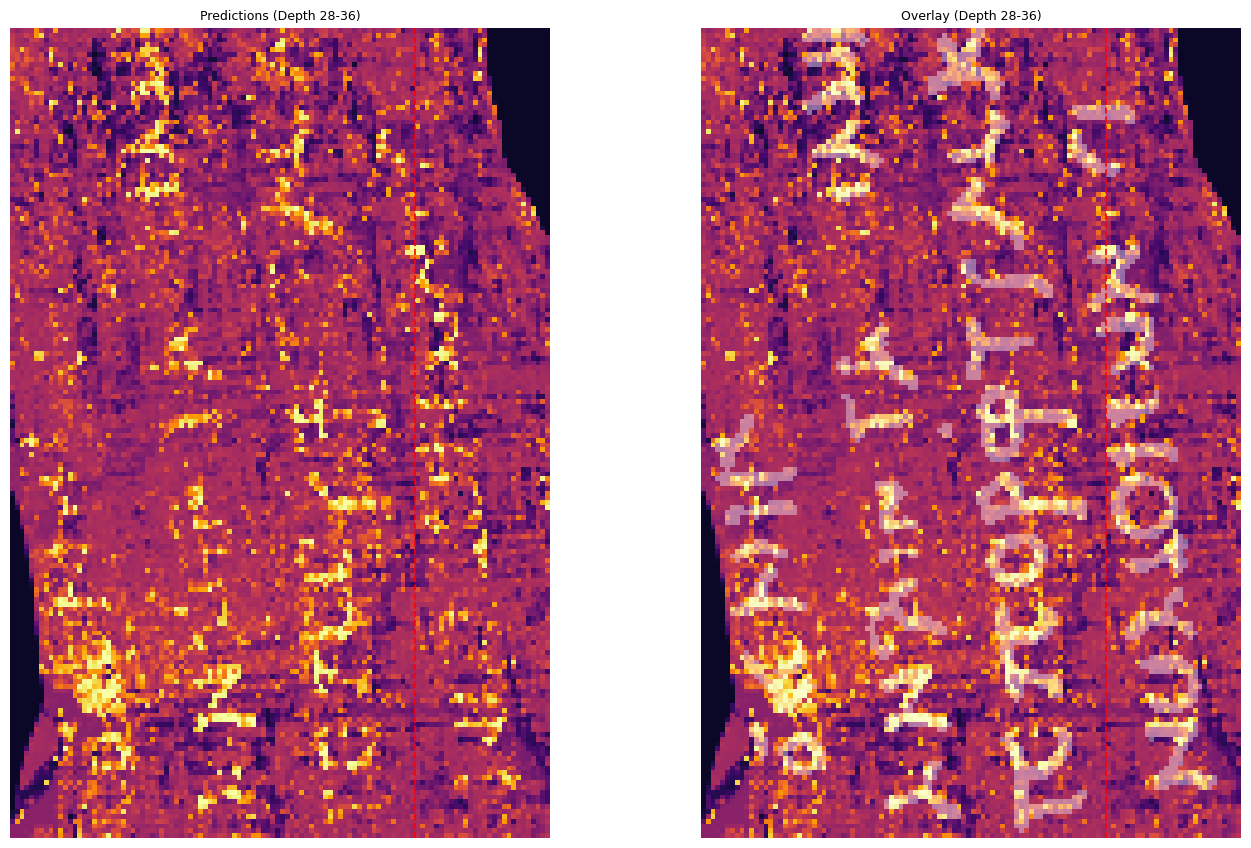

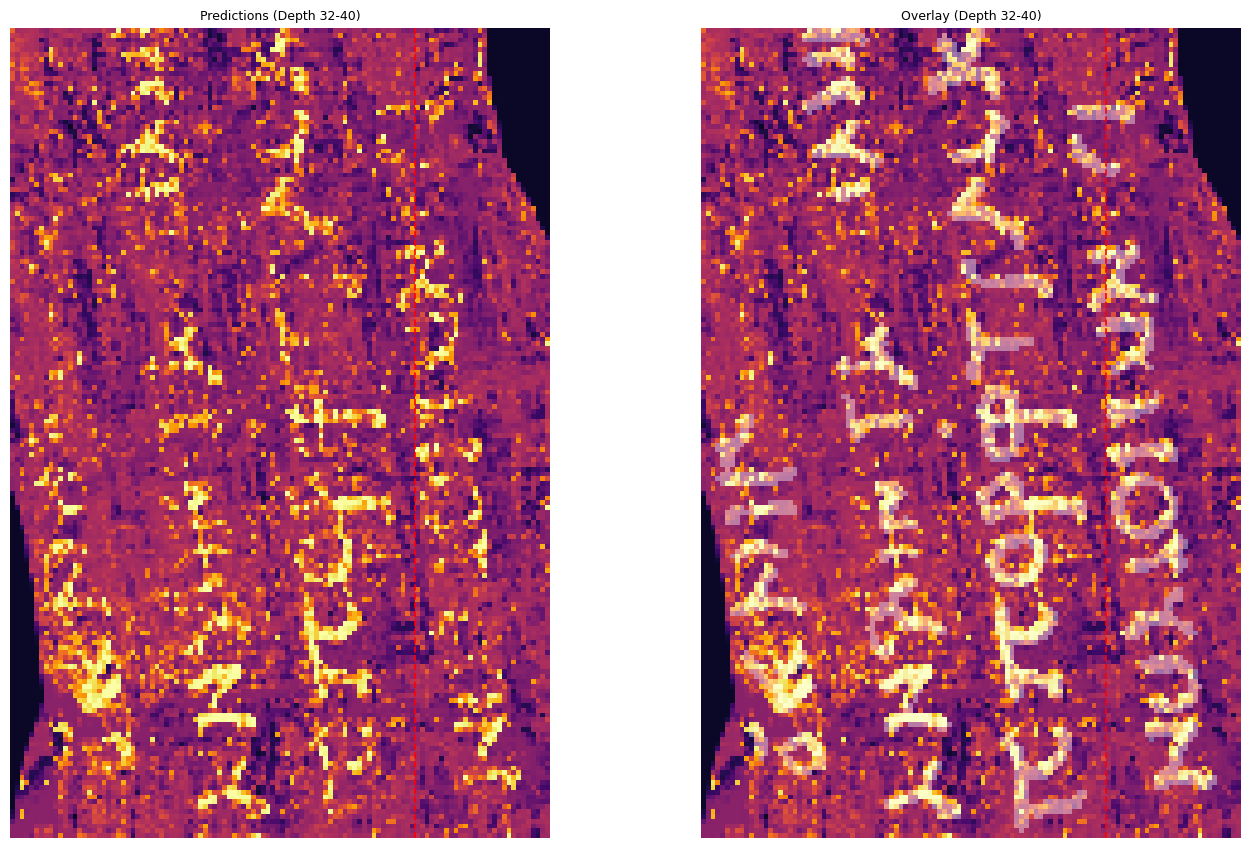

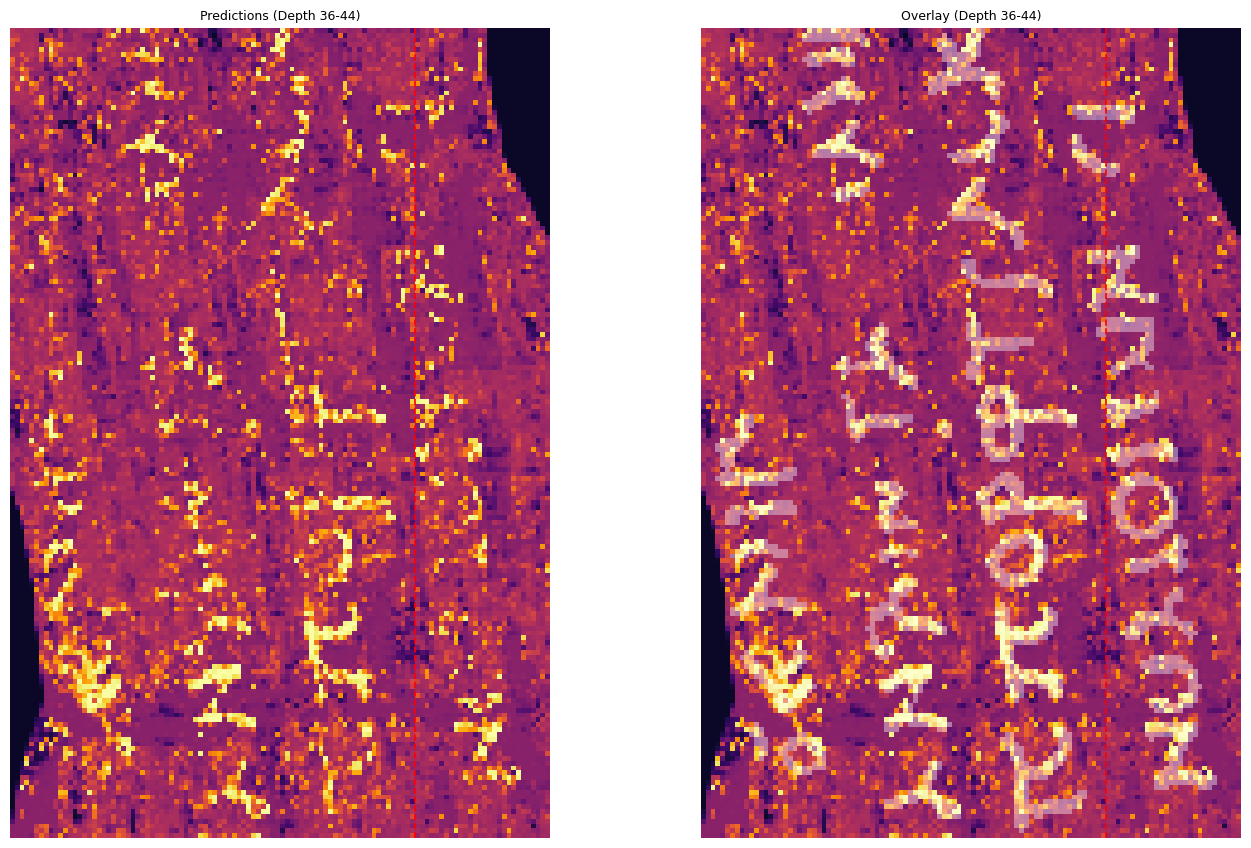

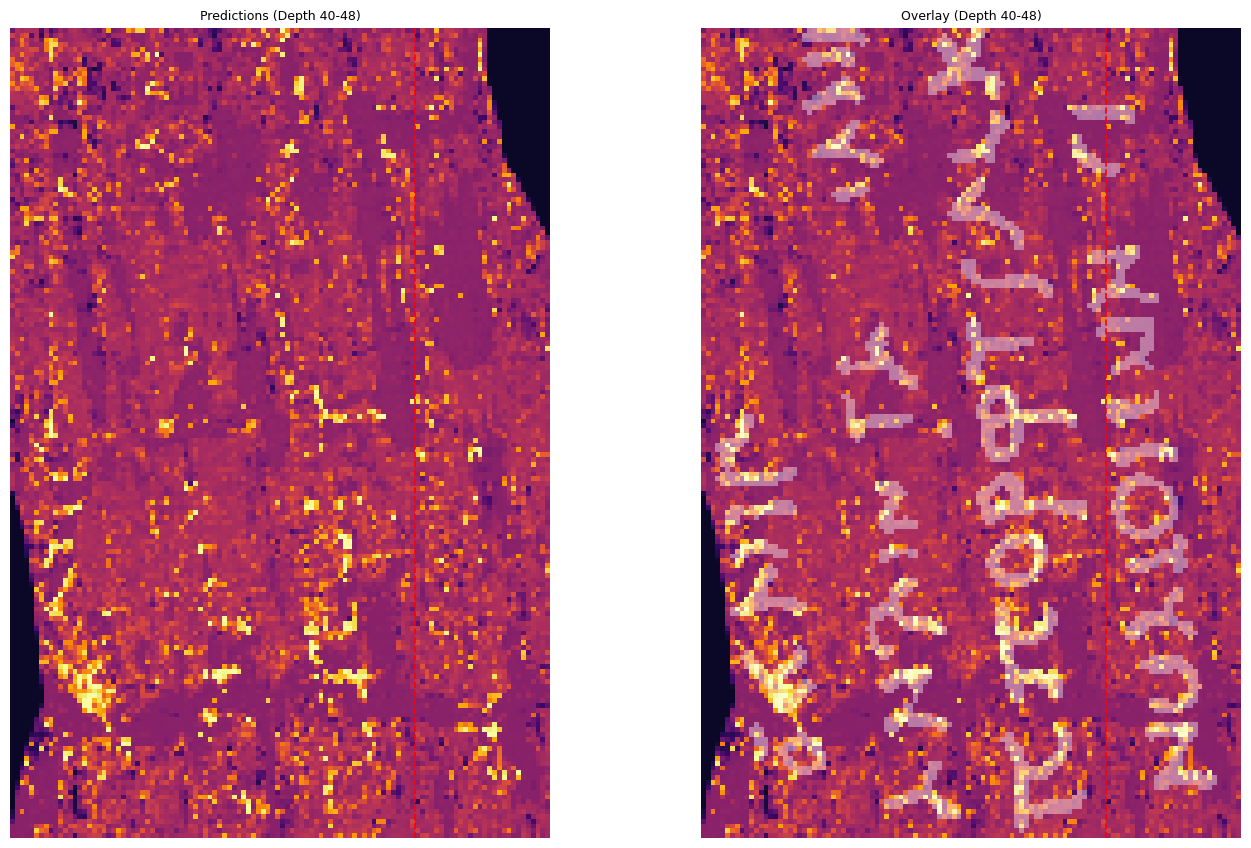

In [25]:
# === Create Evaluation Figures (matching visualizer's _create_evaluation_figure) ===
# Crop labels to match the coordinate ranges
cropped_labels = labels[y_range[0]:y_range[1], train_x_range[0]:valid_x_range[1]]

for prediction_data in all_predictions_data:
    full_predictions, train_predictions, depth_start, depth_end = prediction_data
    
    # Create figure with 2 subplots (predictions + overlay) as visualizer does
    fig, axes = plt.subplots(1, 2, figsize=(15, 9))
    
    # Downsample labels to match prediction map dimensions
    tile_size = config.data.tile_size
    downsampled_labels = cropped_labels[::tile_size, ::tile_size]
    
    # Use zoom factor of 1 as visualizer does
    scaled_labels = ndimage.zoom(downsampled_labels, 1, order=0)
    
    # Left plot: Model predictions
    ax_pred = axes[0]
    im1 = ax_pred.imshow(full_predictions, cmap='inferno', vmin=0, vmax=1, aspect='equal')
    ax_pred.set_title(f'Predictions (Depth {depth_start}-{depth_end})', fontsize=9)
    
    # Add dividing line between train and validation (as visualizer does)
    train_split_pos = train_predictions.shape[1] - 0.5
    ax_pred.axvline(x=train_split_pos, color='red', linestyle='--', linewidth=1.2)
    ax_pred.axis('off')
    
    # Right plot: Predictions + Ground Truth overlay (as visualizer does)
    ax_overlay = axes[1]
    ax_overlay.imshow(full_predictions, cmap='inferno', vmin=0, vmax=1, aspect='equal')
    ax_overlay.set_title(f'Overlay (Depth {depth_start}-{depth_end})', fontsize=9)
    
    if scaled_labels is not None:
        # Create label overlay with white pixels at 40% opacity (as visualizer does)
        label_overlay = np.zeros((*full_predictions.shape, 4))
        h, w = min(scaled_labels.shape[0], label_overlay.shape[0]), min(scaled_labels.shape[1], label_overlay.shape[1])
        label_overlay[:h, :w][scaled_labels[:h, :w] > 0.5] = [1, 1, 1, 0.4]  # White with 40% opacity
        ax_overlay.imshow(label_overlay)
    
    # Add dividing line to overlay as well
    ax_overlay.axvline(x=train_split_pos, color='red', linestyle='--', linewidth=1.2)
    ax_overlay.axis('off')
    
    # Match visualizer's subplot adjustment
    plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.05, right=0.95, top=0.95, bottom=0.05)
    plt.show()